In [1]:
# Installation des dépendances principales
!pip install nltk spacy wordcloud matplotlib scikit-learn

# Télécharger les ressources nécessaires pour nltk & spacy
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

import spacy
!python -m spacy download en_core_web_sm


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import requests
import re

def clean_gutenberg_text(text):
    # Recherche le début et la fin du vrai contenu du livre
    start_pattern = re.compile(r'\*\*\* ?START OF(.*?)\*\*\*', re.IGNORECASE | re.DOTALL)
    end_pattern = re.compile(r'\*\*\* ?END OF(.*?)\*\*\*', re.IGNORECASE | re.DOTALL)

    start_match = start_pattern.search(text)
    end_match = end_pattern.search(text)

    if start_match:
        start_idx = start_match.end()
    else:
        print("Warning: START marker not found, using full text.")
        start_idx = 0

    if end_match:
        end_idx = end_match.start()
    else:
        print("Warning: END marker not found, using full text.")
        end_idx = len(text)

    # Extraction du texte entre les balises trouvées (ou tout le texte si balise manquante)
    clean_text = text[start_idx:end_idx]

    # Nettoyage : garder uniquement lettres, espaces et apostrophes
    clean_text = re.sub(r"[^A-Za-z\s']", ' ', clean_text)
    clean_text = re.sub(r'\s+', ' ', clean_text)
    return clean_text.strip()

def load_texts(urls):
    corpus = []
    for url in urls:
        response = requests.get(url)
        text = response.text

        cleaned = clean_gutenberg_text(text)
        corpus.append(cleaned)
    return corpus

urls = [
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt',  # A Tangled Tale
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',        # Through the Looking Glass
    'https://www.gutenberg.org/cache/epub/11/pg11.txt'         # Alice’s Adventures in Wonderland
]
corpus = load_texts(urls)


In [3]:
for idx, text in enumerate(corpus):
    print(f"\n--- Book {idx+1} ---")
    print(text[:200])



--- Book 1 ---
Produced by Chris Curnow Carla Foust Lindy Walsh and the Online Distributed Proofreading Team at https www pgdp net Music transcribed by Linda Cantoni Transcriber's note Minor punctuation errors have 

--- Book 2 ---
Illustration THROUGH THE LOOKING GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition DRAMATIS PERSON As arranged before commencement of game WHITE RED PIECES PAWNS PAWNS P

--- Book 3 ---
Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION Contents CHAPTER I Down the Rabbit Hole CHAPTER II The Pool of Tears CHAPTER III A Caucus Race and a Long 


In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
import nltk
from nltk.tokenize import word_tokenize

# Tokenisation de chaque livre
tokenized_books = [word_tokenize(book) for book in corpus]

for i, tokens in enumerate(tokenized_books):
    print(f"\n--- Book {i+1} - First 150 tokens ---")
    print(tokens[:150])



--- Book 1 - First 150 tokens ---
['Produced', 'by', 'Chris', 'Curnow', 'Carla', 'Foust', 'Lindy', 'Walsh', 'and', 'the', 'Online', 'Distributed', 'Proofreading', 'Team', 'at', 'https', 'www', 'pgdp', 'net', 'Music', 'transcribed', 'by', 'Linda', 'Cantoni', 'Transcriber', "'s", 'note', 'Minor', 'punctuation', 'errors', 'have', 'been', 'changed', 'without', 'notice', 'Printer', 'errors', 'have', 'been', 'changed', 'and', 'are', 'listed', 'at', 'the', 'end', 'All', 'other', 'inconsistencies', 'are', 'as', 'in', 'the', 'original', 'In', 'this', 'version', 'the', 'square', 'root', 'symbol', 'is', 'indicated', 'by', 'sqrt', 'the', 'superscript', 'by', 'and', 'the', 'therefore', 'symbol', 'by', 'therefore', 'A', 'TANGLED', 'TALE', 'Decoration', 'Illustration', 'AT', 'A', 'PACE', 'OF', 'SIX', 'MILES', 'IN', 'THE', 'HOUR', 'Frontispiece', 'A', 'TANGLED', 'TALE', 'BY', 'LEWIS', 'CARROLL', 'WITH', 'SIX', 'ILLUSTRATIONS', 'BY', 'ARTHUR', 'B', 'FROST', 'Hoc', 'meum', 'tale', 'quale', 'est', 'acci

In [8]:
for i, tokens in enumerate(tokenized_books):
    print(f"Book {i+1}: {len(tokens)} tokens")


Book 1: 27873 tokens
Book 2: 31096 tokens
Book 3: 27428 tokens


In [9]:
for i, tokens in enumerate(tokenized_books):
    unique_tokens = set(tokens)
    print(f"Book {i+1}: {len(unique_tokens)} unique words")


Book 1: 4489 unique words
Book 2: 3136 unique words
Book 3: 2845 unique words


In [10]:
from collections import Counter

for i, tokens in enumerate(tokenized_books):
    counter = Counter(tokens)
    most_common = counter.most_common(20)
    print(f"\n--- Book {i+1} - Top 20 mots fréquents ---")
    for word, freq in most_common:
        print(f"{word}: {freq}")



--- Book 1 - Top 20 mots fréquents ---
the: 1570
of: 727
and: 698
to: 595
a: 526
in: 405
I: 371
that: 348
is: 325
it: 324
as: 241
be: 185
one: 183
's: 177
you: 168
have: 163
was: 153
on: 152
for: 148
with: 147

--- Book 2 - Top 20 mots fréquents ---
the: 1486
and: 773
a: 741
to: 731
I: 662
it: 570
you: 528
she: 484
of: 480
said: 471
Alice: 467
in: 389
was: 353
t: 322
s: 316
that: 313
as: 302
her: 266
on: 247
with: 219

--- Book 3 - Top 20 mots fréquents ---
the: 1535
and: 806
to: 728
a: 620
I: 546
it: 530
she: 513
of: 503
said: 458
Alice: 399
in: 359
was: 356
you: 356
that: 286
as: 246
her: 245
t: 217
s: 204
at: 203
on: 189


In [11]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Supprime les stopwords pour chaque livre
tokenized_books_nostop = []
for tokens in tokenized_books:
    filtered = [word for word in tokens if word.lower() not in stop_words]
    tokenized_books_nostop.append(filtered)

# Vérification : quelques exemples de stopwords
test_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
for idx, tokens in enumerate(tokenized_books_nostop):
    print(f"\n--- Book {idx+1} : présence de stopwords ---")
    for w in test_words:
        print(f"{w} : {tokens.count(w)}")

# Afficher les 30 premiers tokens après suppression pour contrôle visuel
for i, tokens in enumerate(tokenized_books_nostop):
    print(f"\n--- Book {i+1} - First 30 tokens without stopwords ---")
    print(tokens[:30])



--- Book 1 : présence de stopwords ---
i : 0
me : 0
my : 0
myself : 0
we : 0
our : 0
ours : 0
ourselves : 0

--- Book 2 : présence de stopwords ---
i : 0
me : 0
my : 0
myself : 0
we : 0
our : 0
ours : 0
ourselves : 0

--- Book 3 : présence de stopwords ---
i : 0
me : 0
my : 0
myself : 0
we : 0
our : 0
ours : 0
ourselves : 0

--- Book 1 - First 30 tokens without stopwords ---
['Produced', 'Chris', 'Curnow', 'Carla', 'Foust', 'Lindy', 'Walsh', 'Online', 'Distributed', 'Proofreading', 'Team', 'https', 'www', 'pgdp', 'net', 'Music', 'transcribed', 'Linda', 'Cantoni', 'Transcriber', "'s", 'note', 'Minor', 'punctuation', 'errors', 'changed', 'without', 'notice', 'Printer', 'errors']

--- Book 2 - First 30 tokens without stopwords ---
['Illustration', 'LOOKING', 'GLASS', 'Alice', 'Found', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'PERSON', 'arranged', 'commencement', 'game', 'WHITE', 'RED', 'PIECES', 'PAWNS', 'PAWNS', 'PIECES', 'Tweedledee', 'Daisy', 'Daisy', 'Humpt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

# Stemmer les tokens de chaque livre (après suppression des stopwords)
stemmed_books = []
for tokens in tokenized_books_nostop:
    stems = [ps.stem(word) for word in tokens]
    stemmed_books.append(stems)

# Afficher les 50 premiers stems de chaque livre
for i, stems in enumerate(stemmed_books):
    print(f"\n--- Book {i+1} - First 50 stemmed tokens ---")
    print(stems[:50])



--- Book 1 - First 50 stemmed tokens ---
['produc', 'chri', 'curnow', 'carla', 'foust', 'lindi', 'walsh', 'onlin', 'distribut', 'proofread', 'team', 'http', 'www', 'pgdp', 'net', 'music', 'transcrib', 'linda', 'cantoni', 'transcrib', "'s", 'note', 'minor', 'punctuat', 'error', 'chang', 'without', 'notic', 'printer', 'error', 'chang', 'list', 'end', 'inconsist', 'origin', 'version', 'squar', 'root', 'symbol', 'indic', 'sqrt', 'superscript', 'therefor', 'symbol', 'therefor', 'tangl', 'tale', 'decor', 'illustr', 'pace']

--- Book 2 - First 50 stemmed tokens ---
['illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn', 'rose', 'r', 'king', 'age', 'man'

In [13]:
!pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 128.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
import spacy

# Charger le modèle pré-entraîné anglais
nlp = spacy.load('en_core_web_sm')

lemmatized_books = []
for tokens in tokenized_books_nostop:
    # spaCy attend une string, donc on recompose le texte avec les tokens filtrés
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc]
    lemmatized_books.append(lemmas)

# Afficher les 50 premiers lemmes de chaque livre
for i, lemmas in enumerate(lemmatized_books):
    print(f"\n--- Book {i+1} - First 50 lemmatized tokens ---")
    print(lemmas[:50])



--- Book 1 - First 50 lemmatized tokens ---
['produce', 'Chris', 'Curnow', 'Carla', 'Foust', 'Lindy', 'Walsh', 'Online', 'distribute', 'Proofreading', 'Team', 'https', 'www', 'pgdp', 'net', 'Music', 'transcribe', 'Linda', 'Cantoni', 'Transcriber', "'s", 'note', 'minor', 'punctuation', 'error', 'change', 'without', 'notice', 'Printer', 'error', 'change', 'listed', 'end', 'inconsistency', 'original', 'version', 'square', 'root', 'symbol', 'indicate', 'sqrt', 'superscript', 'therefore', 'symbol', 'therefore', 'tangle', 'TALE', 'Decoration', 'Illustration', 'PACE']

--- Book 2 - First 50 lemmatized tokens ---
['illustration', 'look', 'GLASS', 'Alice', 'find', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'person', 'arrange', 'commencement', 'game', 'WHITE', 'RED', 'piece', 'pawns', 'pawns', 'PIECES', 'Tweedledee', 'Daisy', 'Daisy', 'Humpty', 'Dumpty', 'Unicorn', 'Haigha', 'Messenger', 'Carpenter', 'Sheep', 'Oyster', 'Oyster', 'Walrus', 'W', 'Queen', 'Lily', 'Tiger', 

In [15]:
# Prendre le premier livre comme exemple (indice 0)
print("--- Mot original | Stem | Lemma ---")
for orig, stem, lemma in zip(tokenized_books_nostop[0][:50], stemmed_books[0][:50], lemmatized_books[0][:50]):
    print(f"{orig:15s} | {stem:10s} | {lemma}")


--- Mot original | Stem | Lemma ---
Produced        | produc     | produce
Chris           | chri       | Chris
Curnow          | curnow     | Curnow
Carla           | carla      | Carla
Foust           | foust      | Foust
Lindy           | lindi      | Lindy
Walsh           | walsh      | Walsh
Online          | onlin      | Online
Distributed     | distribut  | distribute
Proofreading    | proofread  | Proofreading
Team            | team       | Team
https           | http       | https
www             | www        | www
pgdp            | pgdp       | pgdp
net             | net        | net
Music           | music      | Music
transcribed     | transcrib  | transcribe
Linda           | linda      | Linda
Cantoni         | cantoni    | Cantoni
Transcriber     | transcrib  | Transcriber
's              | 's         | 's
note            | note       | note
Minor           | minor      | minor
punctuation     | punctuat   | punctuation
errors          | error      | error
changed       

# Différence entre stemming et lemmatization


# - Le stemming coupe les fins de mots sans tenir compte de la grammaire ou du sens, produisant parfois des racines qui ne sont pas de vrais mots.
# - La lemmatisation retourne la forme de dictionnaire correcte (ex: "was" devient "be", "better" devient "good").
# - La lemmatisation est donc plus précise et utile pour la plupart des analyses linguistiques, mais plus coûteuse en calcul.


In [17]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# On fait le POS tagging sur les tokens filtrés (sans stopwords)
pos_tagged_books = []
for tokens in tokenized_books_nostop:
    tags = nltk.pos_tag(tokens)
    pos_tagged_books.append(tags)

# Afficher les 30 premiers tags pour chaque livre
for i, tagged in enumerate(pos_tagged_books):
    print(f"\n--- Book {i+1} - First 30 POS tags ---")
    print(tagged[:30])


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.



--- Book 1 - First 30 POS tags ---
[('Produced', 'NNP'), ('Chris', 'NNP'), ('Curnow', 'NNP'), ('Carla', 'NNP'), ('Foust', 'NNP'), ('Lindy', 'NNP'), ('Walsh', 'NNP'), ('Online', 'NNP'), ('Distributed', 'NNP'), ('Proofreading', 'NNP'), ('Team', 'NNP'), ('https', 'NN'), ('www', 'NN'), ('pgdp', 'JJ'), ('net', 'JJ'), ('Music', 'NNP'), ('transcribed', 'NN'), ('Linda', 'NNP'), ('Cantoni', 'NNP'), ('Transcriber', 'NNP'), ("'s", 'POS'), ('note', 'NN'), ('Minor', 'NNP'), ('punctuation', 'NN'), ('errors', 'NNS'), ('changed', 'VBD'), ('without', 'IN'), ('notice', 'NN'), ('Printer', 'NNP'), ('errors', 'NNS')]

--- Book 2 - First 30 POS tags ---
[('Illustration', 'NN'), ('LOOKING', 'NNP'), ('GLASS', 'NNP'), ('Alice', 'NNP'), ('Found', 'NNP'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('Millennium', 'NNP'), ('Fulcrum', 'NNP'), ('Edition', 'NNP'), ('DRAMATIS', 'NNP'), ('PERSON', 'NNP'), ('arranged', 'VBD'), ('commencement', 'JJ'), ('game', 'NN'), ('WHITE', 'NNP'), ('RED', 'NNP'), ('PIECES', 'NNP'), ('PAW

In [19]:
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')

from nltk import ne_chunk

# Prendre les POS tags de chaque livre (fait à l’étape précédente)
# ne_chunk attend une séquence de tuples (word, POS)

ner_books = []
for tags in pos_tagged_books:
    # On découpe en petits morceaux pour éviter la surcharge mémoire
    # (exemple : on prend les 200 premiers tokens pour la démo)
    ner = ne_chunk(tags[:200])
    ner_books.append(ner)

# Affichage (pour les 200 premiers tokens de chaque livre)
for i, ner in enumerate(ner_books):
    print(f"\n--- Book {i+1} - Named Entities (first 200 tokens) ---")
    print(ner)


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.



--- Book 1 - Named Entities (first 200 tokens) ---
(S
  Produced/NNP
  (PERSON
    Chris/NNP
    Curnow/NNP
    Carla/NNP
    Foust/NNP
    Lindy/NNP
    Walsh/NNP
    Online/NNP
    Distributed/NNP)
  Proofreading/NNP
  Team/NNP
  https/NN
  www/NN
  pgdp/JJ
  net/JJ
  Music/NNP
  transcribed/NN
  (PERSON Linda/NNP Cantoni/NNP)
  Transcriber/NNP
  's/POS
  note/NN
  Minor/NNP
  punctuation/NN
  errors/NNS
  changed/VBD
  without/IN
  notice/NN
  Printer/NNP
  errors/NNS
  changed/VBD
  listed/JJ
  end/NN
  inconsistencies/NNS
  original/JJ
  version/NN
  square/NN
  root/NN
  symbol/NN
  indicated/VBD
  sqrt/JJ
  superscript/NN
  therefore/RB
  symbol/VBD
  therefore/RB
  (ORGANIZATION TANGLED/NNP)
  TALE/NNP
  Decoration/NNP
  Illustration/NNP
  PACE/NNP
  SIX/NNP
  MILES/NNP
  HOUR/NNP
  Frontispiece/NNP
  TANGLED/NNP
  TALE/NNP
  LEWIS/NNP
  CARROLL/NNP
  SIX/NNP
  ILLUSTRATIONS/NNP
  ARTHUR/NNP
  B/NNP
  FROST/NNP
  Hoc/NNP
  meum/NN
  tale/NN
  quale/NN
  est/JJS
  accipe/JJ
  (

In [20]:
import spacy

# Charger le modèle pré-entraîné anglais (si ce n'est pas déjà fait)
nlp = spacy.load('en_core_web_sm')

# Extraire les entités pour chaque livre
entities_books = []
for tokens in tokenized_books_nostop:
    doc = nlp(" ".join(tokens))
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    entities_books.append(entities)

# Afficher les 30 premières entités pour chaque livre
for i, entities in enumerate(entities_books):
    print(f"\n--- Book {i+1} - First 30 named entities ---")
    print(entities[:30])



--- Book 1 - First 30 named entities ---
[('Chris', 'PERSON'), ('Carla Foust', 'PERSON'), ('Lindy Walsh', 'PERSON'), ('Music', 'PRODUCT'), ('Linda Cantoni', 'PERSON'), ('Transcriber', 'PERSON'), ('SIX', 'CARDINAL'), ('FROST Hoc', 'PERSON'), ('SECOND', 'ORDINAL'), ('London MACMILLAN CO Rights Reserved RICHARD', 'ORG'), ('Addish Subtrac Multiplica', 'PERSON'), ('Three', 'CARDINAL'), ('Exceeding', 'PERSON'), ('Euclid', 'PERSON'), ('PREFACE Tale', 'ORG'), ('Monthly', 'DATE'), ('April', 'DATE'), ('one', 'CARDINAL'), ('Algebra Geometry', 'PERSON'), ('Magazine L', 'ORG'), ('October', 'DATE'), ('two', 'CARDINAL'), ('six miles hour', 'QUANTITY'), ('first', 'ORDINAL'), ('three miles hour', 'QUANTITY'), ('Four miles hour', 'QUANTITY'), ('three hours', 'TIME'), ('noon', 'TIME'), ('nine', 'CARDINAL'), ('exact minute', 'TIME')]

--- Book 2 - First 30 named entities ---
[('WHITE RED PIECES PAWNS PAWNS', 'ORG'), ('Tweedledee Daisy Daisy Humpty Dumpty', 'PERSON'), ('Fawn Rose R King', 'PERSON'), ('Oys

2

In [21]:
!pip install wordcloud matplotlib


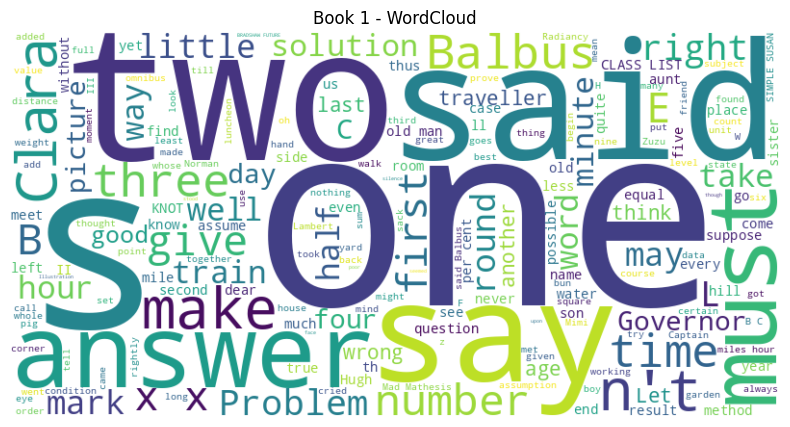

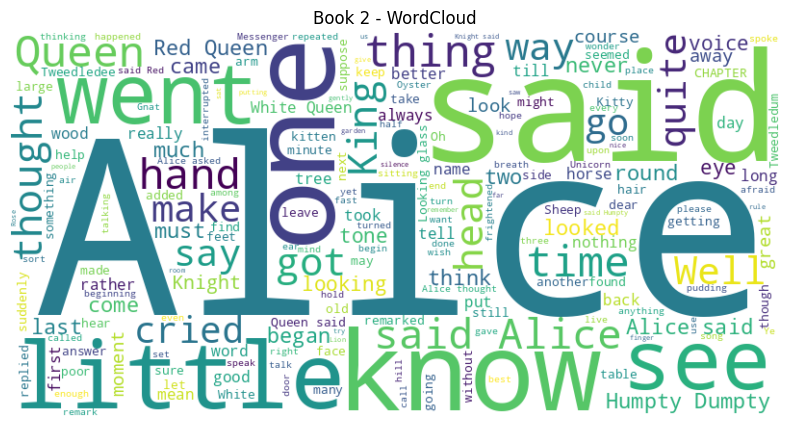

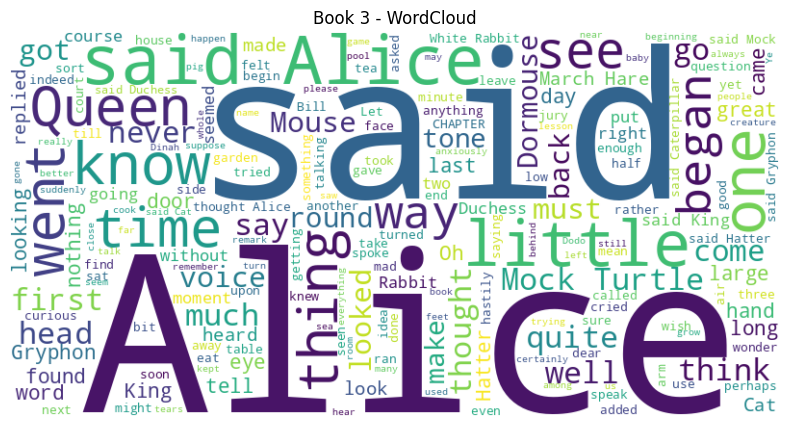

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for i, tokens in enumerate(tokenized_books_nostop):
    text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f'Book {i+1} - WordCloud')
    plt.show()


In [23]:
from collections import Counter

# Fusionne tous les livres lemmatisés
all_lemmas = []
for lemmas in lemmatized_books:
    all_lemmas.extend(lemmas)

counter = Counter(all_lemmas)
most_common_5 = counter.most_common(5)
print("Top 5 most frequent words across all books:", most_common_5)


Top 5 most frequent words across all books: [('say', 1303), ('Alice', 864), ('one', 473), ('go', 417), ('get', 307)]


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# On recompose les textes lemmatisés
docs = [" ".join(lemmas) for lemmas in lemmatized_books]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

# Parcourir les 5 mots les plus fréquents et afficher leur index, document, count
feature_names = vectorizer.get_feature_names_out()

for word, _ in most_common_5:
    if word in feature_names:
        idx = list(feature_names).index(word)
        for doc_idx in range(X.shape[0]):
            count = X[doc_idx, idx]
            print(f"Document {doc_idx+1}, word '{word}' (index {idx}), count: {count}")


Document 1, word 'say' (index 3577), count: 233
Document 2, word 'say' (index 3577), count: 541
Document 3, word 'say' (index 3577), count: 530
Document 1, word 'one' (index 2893), count: 214
Document 2, word 'one' (index 2893), count: 155
Document 3, word 'one' (index 2893), count: 105
Document 1, word 'go' (index 1798), count: 69
Document 2, word 'go' (index 1798), count: 179
Document 3, word 'go' (index 1798), count: 170
Document 1, word 'get' (index 1762), count: 54
Document 2, word 'get' (index 1762), count: 148
Document 3, word 'get' (index 1762), count: 105


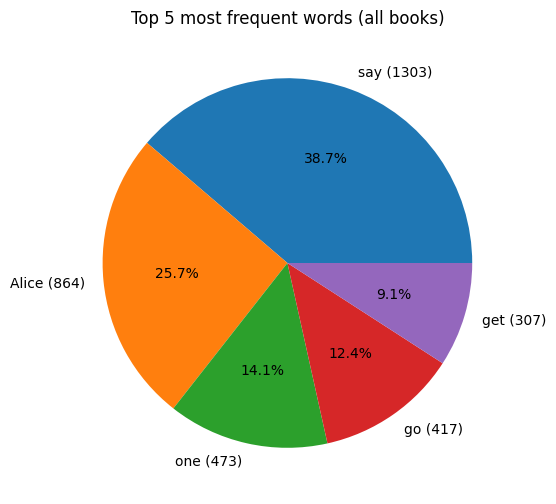

In [25]:
labels = [word for word, count in most_common_5]
sizes = [count for word, count in most_common_5]
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=[f"{l} ({s})" for l, s in zip(labels, sizes)], autopct='%1.1f%%')
plt.title('Top 5 most frequent words (all books)')
plt.show()


On remarque que les mots les plus fréquents sont surtout des termes génériques ou des noms récurrents du livre. Ils sont donc peu informatifs pour une analyse de contenu, ce qui justifie l’usage de TF-IDF pour identifier des mots plus pertinents.


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=1, max_df=2)
X_tfidf = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

# Trouver les 5 mots les plus pertinents pour chaque document
for doc_idx in range(X_tfidf.shape[0]):
    doc_vector = X_tfidf[doc_idx].toarray().flatten()
    top5_idx = doc_vector.argsort()[-5:][::-1]
    top5_words = [(feature_names[i], doc_vector[i]) for i in top5_idx]
    print(f"\nBook {doc_idx+1} - Top 5 TF-IDF words:", top5_words)



Book 1 - Top 5 TF-IDF words: [('not', np.float64(0.30479251570326693)), ('balbus', np.float64(0.29644203582098566)), ('clara', np.float64(0.2630401162918605)), ('problem', np.float64(0.18788579735132893)), ('train', np.float64(0.16829501247877932))]

Book 2 - Top 5 TF-IDF words: [('dumpty', np.float64(0.35391805670537857)), ('humpty', np.float64(0.35391805670537857)), ('knight', np.float64(0.2835832940507584)), ('tweedledum', np.float64(0.23383871603748227)), ('tweedledee', np.float64(0.18327899365099962))]

Book 3 - Top 5 TF-IDF words: [('gryphon', np.float64(0.3321350959677807)), ('rabbit', np.float64(0.32609627604109376)), ('turtle', np.float64(0.2847460488690865)), ('hatter', np.float64(0.2617826578312569)), ('mock', np.float64(0.2617826578312569))]


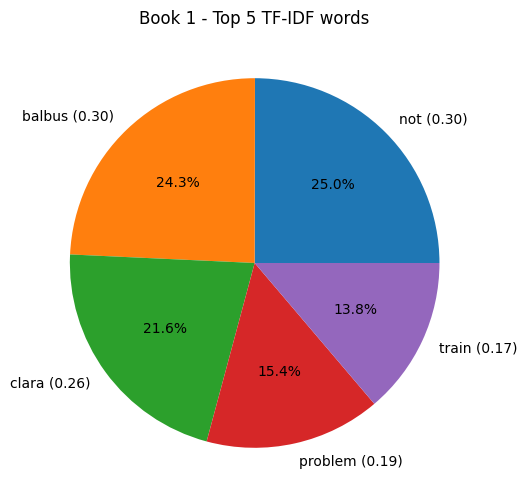

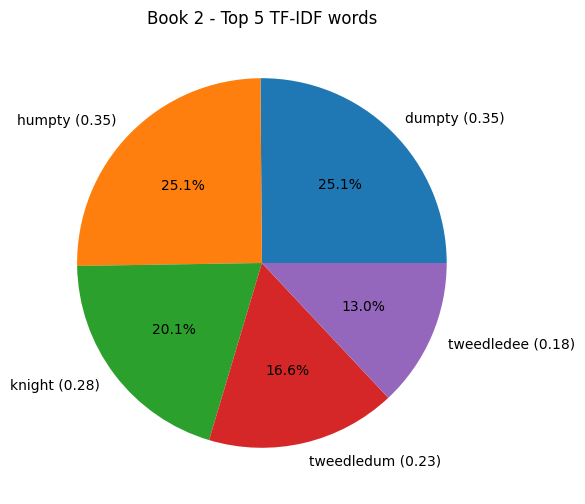

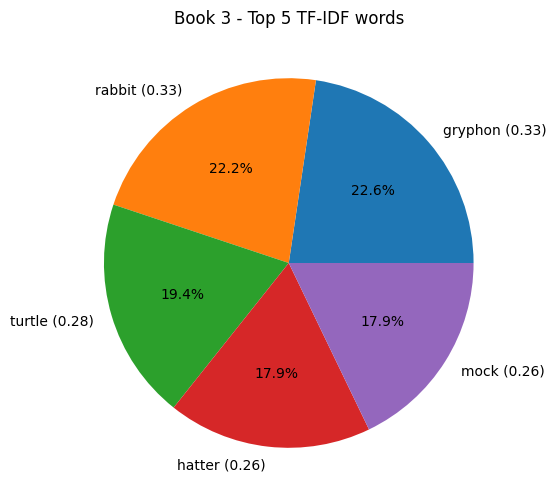

In [27]:
for doc_idx in range(X_tfidf.shape[0]):
    doc_vector = X_tfidf[doc_idx].toarray().flatten()
    top5_idx = doc_vector.argsort()[-5:][::-1]
    labels = [feature_names[i] for i in top5_idx]
    sizes = [doc_vector[i] for i in top5_idx]
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=[f"{l} ({s:.2f})" for l, s in zip(labels, sizes)], autopct='%1.1f%%')
    plt.title(f'Book {doc_idx+1} - Top 5 TF-IDF words')
    plt.show()


In [29]:
!git add .
!git commit -m "Ajout du notebook NLP"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [31]:

%cd /content/drive/MyDrive/AI-exercises-checker
!git add S6/J1/MonExerciceNLP.ipynb
!git commit -m "Ajout de l'exercice NLP Semaine 6 Jour 1"
!git push


[Errno 2] No such file or directory: '/content/drive/MyDrive/AI-exercises-checker'
/content
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
